In [ ]:
import os
import re
import batteryml
from batteryml.visualization.plot_helper import plot_capacity_degradation
from batteryml.data import BatteryData

folder_path = '/Mart'
b1_series = []

# Define a custom sort key that extracts the number following 'c'
def numeric_key(filename):
    # This regex looks for 'c' followed by one or more digits
    match = re.search(r'c(\d+)', filename)
    return int(match.group(1)) if match else 0

# List files that contain 'b1' and end with '.pkl'
files = [f for f in os.listdir(folder_path) if 'b1' in f and f.endswith('.pkl')]

# Sort the files based on the numeric value following 'c'
sorted_files = sorted(files, key=numeric_key)

# Load the files in sorted order into the dictionary
for filename in sorted_files:
    file_path = os.path.join(folder_path, filename)
    data = BatteryData.load(file_path)
    b1_series.append(data)

print("Loaded files in sorted order:")
for f in sorted_files:
    print(f)

Loaded files in sorted order:
MATR_b1c0.pkl
MATR_b1c1.pkl
MATR_b1c2.pkl
MATR_b1c3.pkl
MATR_b1c4.pkl
MATR_b1c5.pkl
MATR_b1c6.pkl
MATR_b1c7.pkl
MATR_b1c8.pkl
MATR_b1c9.pkl
MATR_b1c10.pkl
MATR_b1c11.pkl
MATR_b1c12.pkl
MATR_b1c13.pkl
MATR_b1c14.pkl
MATR_b1c15.pkl
MATR_b1c16.pkl
MATR_b1c17.pkl
MATR_b1c18.pkl
MATR_b1c19.pkl
MATR_b1c20.pkl
MATR_b1c21.pkl
MATR_b1c22.pkl
MATR_b1c23.pkl
MATR_b1c24.pkl
MATR_b1c25.pkl
MATR_b1c26.pkl
MATR_b1c27.pkl
MATR_b1c28.pkl
MATR_b1c29.pkl
MATR_b1c30.pkl
MATR_b1c31.pkl
MATR_b1c32.pkl
MATR_b1c33.pkl
MATR_b1c34.pkl
MATR_b1c35.pkl
MATR_b1c36.pkl
MATR_b1c37.pkl
MATR_b1c38.pkl
MATR_b1c39.pkl
MATR_b1c40.pkl
MATR_b1c41.pkl
MATR_b1c42.pkl
MATR_b1c43.pkl
MATR_b1c44.pkl
MATR_b1c45.pkl


In [2]:
# delete some cases due to the distribution 
del b1_series[0]
del b1_series[17]
del b1_series[7]
del b1_series[8]
del b1_series[9:11]
del b1_series[16]

In [3]:
import numpy as np

def extract_capacity_series(battery_data, normalize=True):
    """
    Parameters
    ----------
    battery_data : Iterable[BatteryData]
        The same iterable you pass to `plot_capacity_degradation`.
    normalize : bool, default True
        If True, divide each cycle’s capacity by the nominal capacity so
        every curve starts near 1.0.

    Returns
    -------
    dict
        {cell_id : numpy.ndarray}  One entry per cell.
        Each value is a 1-D array of capacity values ordered by cycle number.
    """
    capacity_dict = {}

    for cell in battery_data:
        tag = cell.cell_id                      # e.g. 'MATR_b1c20'
        nominal = cell.nominal_capacity_in_Ah   # float

        # take the maximum discharge capacity in each cycle
        q_ds = [max(cycle.discharge_capacity_in_Ah)
                for cycle in cell.cycle_data]

        if normalize:
            q_ds = np.array(q_ds) / nominal
        else:
            q_ds = np.array(q_ds)

        capacity_dict[tag] = q_ds

    return capacity_dict


cap_dict = extract_capacity_series(b1_series, normalize=False)
for tag, arr in cap_dict.items():
    print(f"{tag}: {arr[:5]}  (total {len(arr)} cycles)")

MATR_b1c1: [1.0753012 1.0766124 1.0772982 1.0781505 1.078544 ]  (total 2158 cycles)
MATR_b1c2: [1.0799223 1.0813154 1.082234  1.0827312 1.0830303]  (total 2235 cycles)
MATR_b1c3: [1.0797229 1.0812283 1.0819938 1.0827308 1.083112 ]  (total 1432 cycles)
MATR_b1c4: [1.0784167 1.0790124 1.0797466 1.0804269 1.0807526]  (total 1707 cycles)
MATR_b1c5: [1.0761266 1.0766531 1.0775996 1.0785232 1.0790976]  (total 1072 cycles)
MATR_b1c6: [1.0758358 1.0772603 1.0784051 1.0791821 1.0798916]  (total 634 cycles)
MATR_b1c7: [1.0938644 1.0951102 1.0959545 1.0964732 1.0969613]  (total 868 cycles)
MATR_b1c9: [1.0829742 1.0836858 1.0842299 1.0847102 1.0852641]  (total 1052 cycles)
MATR_b1c11: [1.0537786 1.0550324 1.0558786 1.0564448 1.0570793]  (total 786 cycles)
MATR_b1c14: [1.0709661 1.0721085 1.0724825 1.0733926 1.0739669]  (total 878 cycles)
MATR_b1c15: [1.0611236 1.0627433 1.0637267 1.0646247 1.0652857]  (total 717 cycles)
MATR_b1c16: [1.0811664 1.0823848 1.0833585 1.0840898 1.0846543]  (total 860 cy

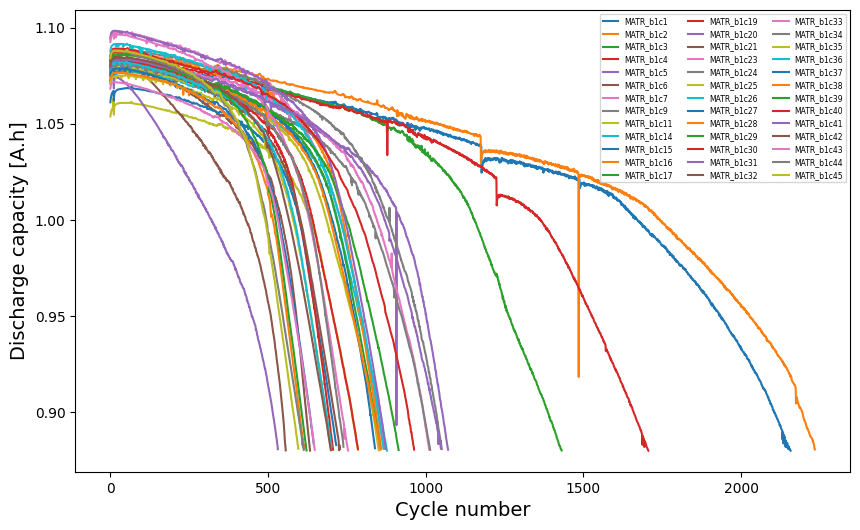

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for key, df in cap_dict.items():
    plt.plot(df, label=key)
plt.legend(ncol=3,fontsize=5.5)
plt.xlabel('Cycle number',fontsize=14)
plt.ylabel('Discharge capacity [A.h]',fontsize=14)

In [5]:
del cap_dict['MATR_b1c1']
del cap_dict['MATR_b1c2']
del cap_dict['MATR_b1c5']
del cap_dict['MATR_b1c20']
del cap_dict['MATR_b1c21']


In [6]:
"""To simply give an explaination about this table, it is the combined one predicted from XGBOOST's 
lower bound for plating parameter with related id, sei parameter, plating parameter, crate and breakpoints
"""

import pandas as pd
df_b1 = pd.read_csv('xgb_cap_50_lower.csv')
breakpoint = df_b1[['id','b1','b2']]


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

folder_path = "benchmark"

# Initialize an empty dictionary to store the DataFrames
data = {}

# Loop through all the .csv files in the folder
for filename in os.listdir(folder_path):    
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        # Store the DataFrame in the dictionary with the filename as the key
        data[filename] = df



Text(0, 0.5, 'Capacity')

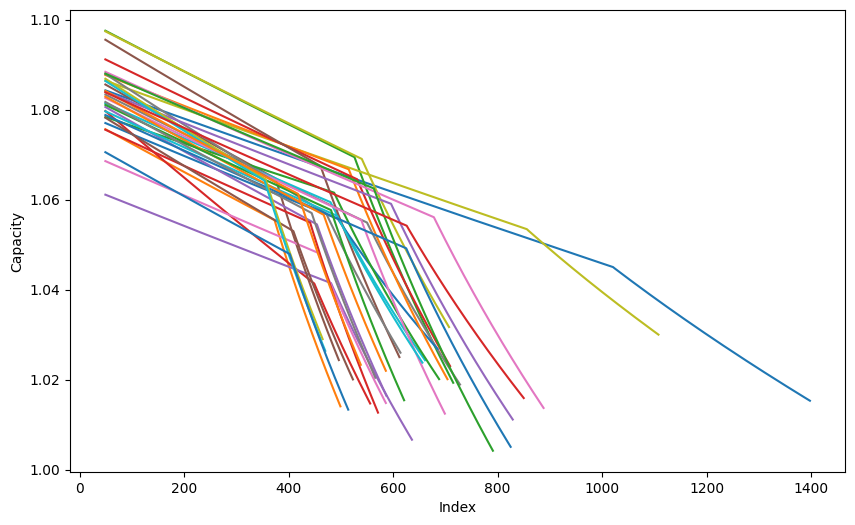

In [8]:
import matplotlib.pyplot as plt
# Plot the data
plt.figure(figsize=(10, 6))

for key, df in data.items():
    label_info = f"SEI: {df['SEI reaction exchange current density [A.m-2]'][0]}, " \
                 f"Dead lithium: {df['Dead lithium decay constant [s-1]'][0]}"
    plt.plot(df['Capacity'].iloc[49:], label=f"{label_info}")

plt.xlabel("Index")
plt.ylabel("Capacity")

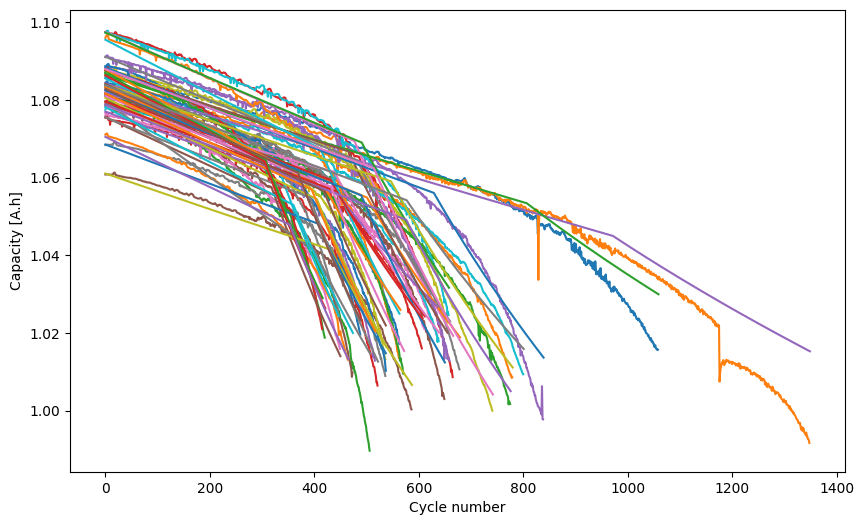

In [ ]:
plt.figure(figsize=(10,6))

# cap_dict
for key, df in cap_dict.items():
    bat_id = key.split('_')[1]   
    row = breakpoint.loc[breakpoint['id'] == bat_id, 'b2']
    if not row.empty:
        bp = int(row.values[0])    
        y = df[49:bp-1]   
        x = range(len(y)) 
        plt.plot(x, y, label=bat_id)

# data 
for key, df in data.items():
    label_info = f"SEI: {df['SEI reaction exchange current density [A.m-2]'][0]}, " \
                 f"Dead lithium: {df['Dead lithium decay constant [s-1]'][0]}"
    y = df['Capacity'].iloc[49:] 
    x = range(len(y))            
    plt.plot(x, y, label=f"{label_info}")

plt.xlabel('Cycle number')
plt.ylabel('Capacity [A.h]')
# plt.legend()
plt.show()

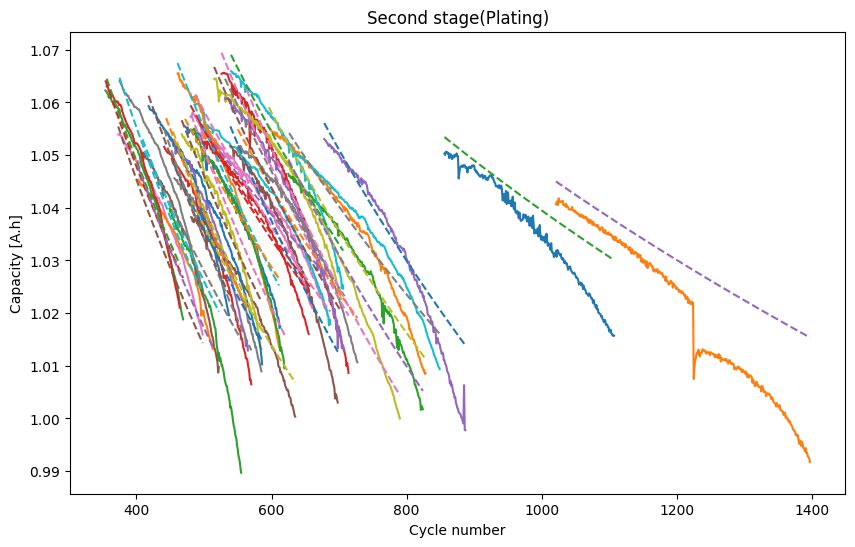

In [ ]:

plt.figure(figsize=(10,6))

# === Part 1: plot experimental curves ===
for key, df in cap_dict.items():
    bat_id = key.split('_')[1]   
    row = breakpoint.loc[breakpoint['id'] == bat_id, ['b1','b2']]
    if not row.empty:
        b1 = int(row['b1'].values[0])
        b2 = int(row['b2'].values[0])
        x = range(b1-1, b2-1)
        y = df[b1-1:b2-1]
        plt.plot(x, y, label='MATR_b1' if key == sorted(cap_dict.keys())[0] else "")

# === Part 2: plot simulation results ===
for key, df in data.items():
    bat_id = key.replace('.csv','')  
    row = breakpoint.loc[breakpoint['id'] == bat_id, ['b1','b2']]
    if not row.empty:
        b1 = int(row['b1'].values[0])
        b2 = int(row['b2'].values[0])
        x = df.index[b1-1:b2-1]
        y = df['Capacity'].iloc[b1-1:b2-1]

        label_info = (
            f"SEI: {df['SEI reaction exchange current density [A.m-2]'].iloc[0]}, "
            f"Dead Li: {df['Dead lithium decay constant [s-1]'].iloc[0]}"
        )
        plt.plot(x, y, '--', label=label_info)

plt.xlabel('Cycle number')
plt.ylabel('Capacity [A.h]')
plt.title('Second stage(Plating)')
# plt.legend()
plt.show()